In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from torchvision import transforms
import os, sys
import cv2
import torch.nn.functional as F

sys.path.append('/home/s5820023/Desktop/MC/stage1_spillnet')
from model_spillnet import SpillNet
from postprocess import despill_postprocess

DEVICE     = 'cuda'
CKPT       = '/home/s5820023/Desktop/MC/checkpoints/best.pth'
IMAGE_PATH = '/home/s5820023/Desktop/MC/dataset/image'
FG_PATH    = '/home/s5820023/Desktop/MC/dataset/fg'
ALPHA_PATH = '/home/s5820023/Desktop/MC/dataset/alpha'
TEST_DIR   = '/home/s5820023/Desktop/MC/dataset/test'
FG_DIR     = '/home/s5820023/Desktop/MC/dataset/fg'
INFER_SIZE = 512

print('imports done')


imports done


In [6]:
model = SpillNet(base=64).to(DEVICE)
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.eval()
print('spillnet loaded')

spillnet loaded


In [7]:
sys.path.insert(0, '/home/s5820023/Desktop/MC/sam2')

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

SAM2_CKPT   = '/home/s5820023/Desktop/MC/checkpoints/sam2/sam2.1_hiera_large.pt'
SAM2_CONFIG = 'configs/sam2.1/sam2.1_hiera_l.yaml'

sam2_model = build_sam2(SAM2_CONFIG, SAM2_CKPT, device=DEVICE)
predictor  = SAM2ImagePredictor(sam2_model)
print('sam2 loaded')

sam2 loaded


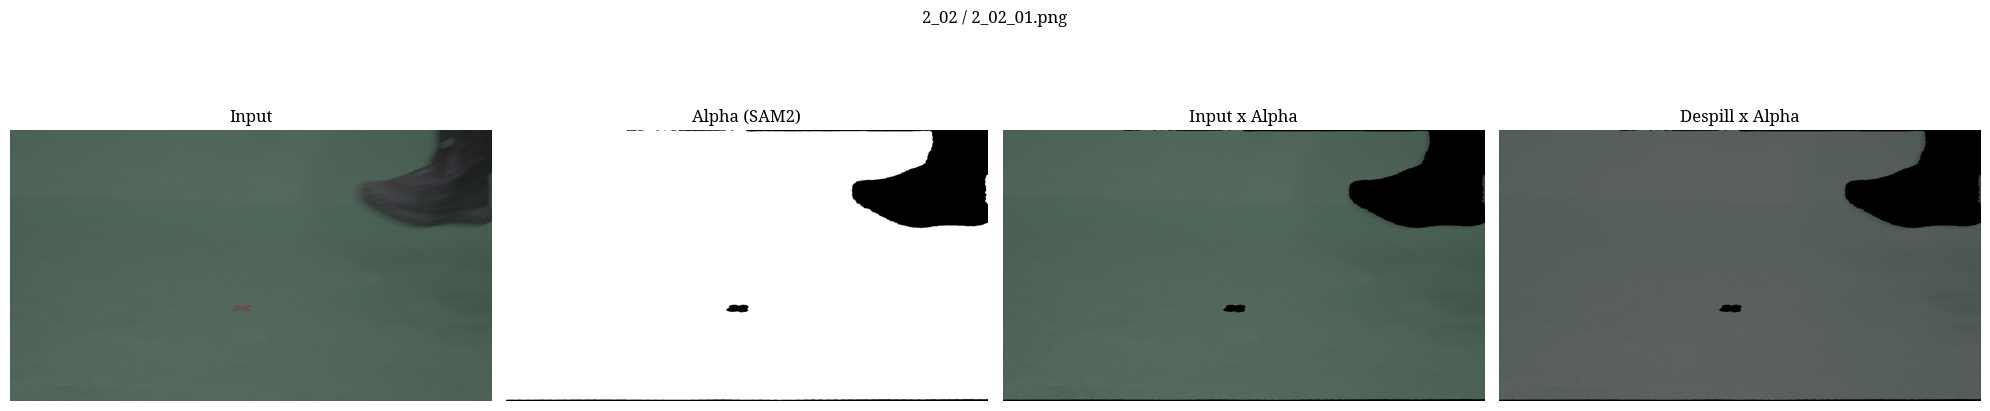

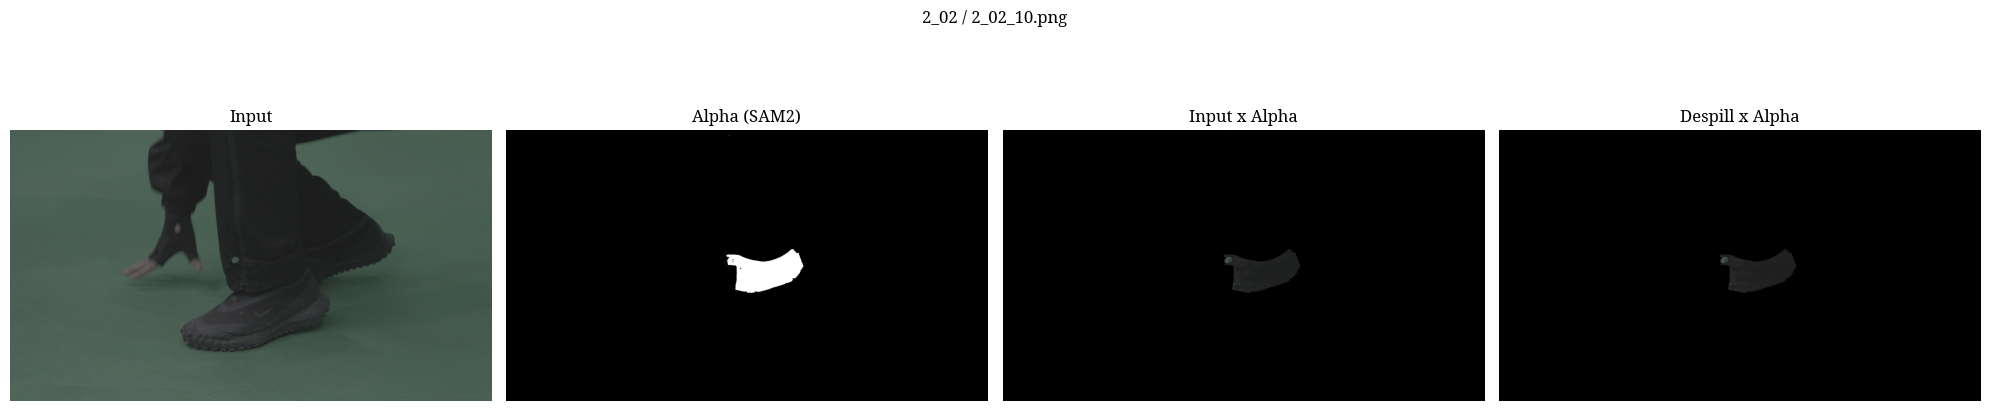

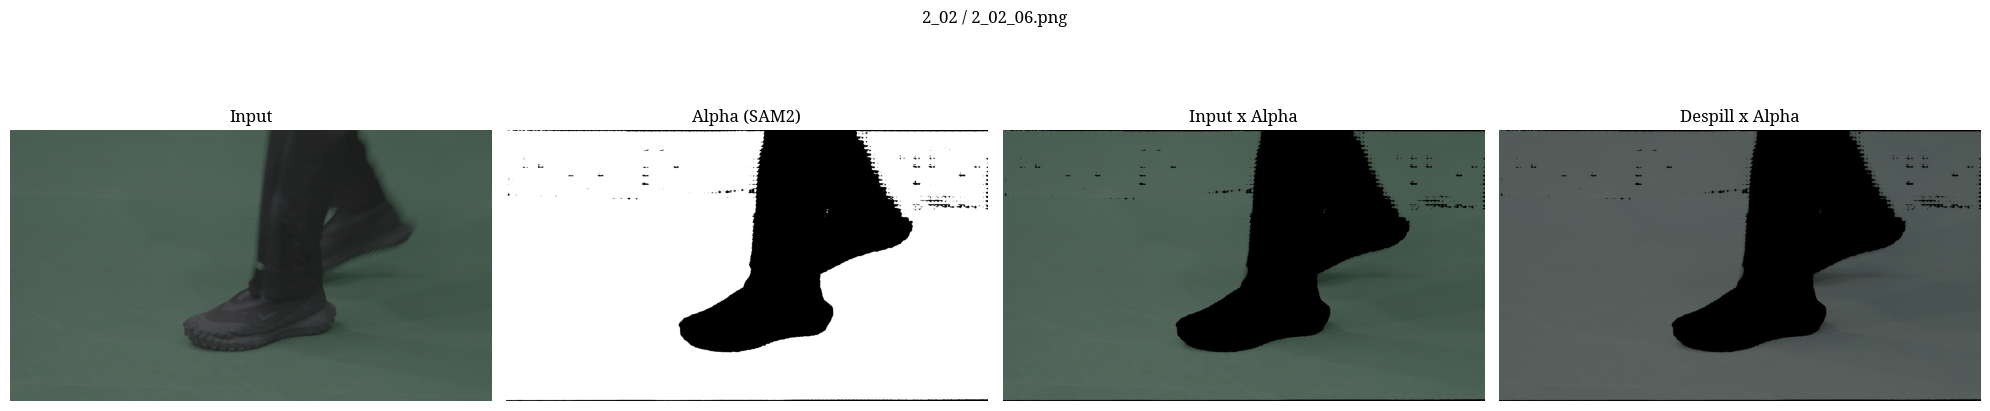

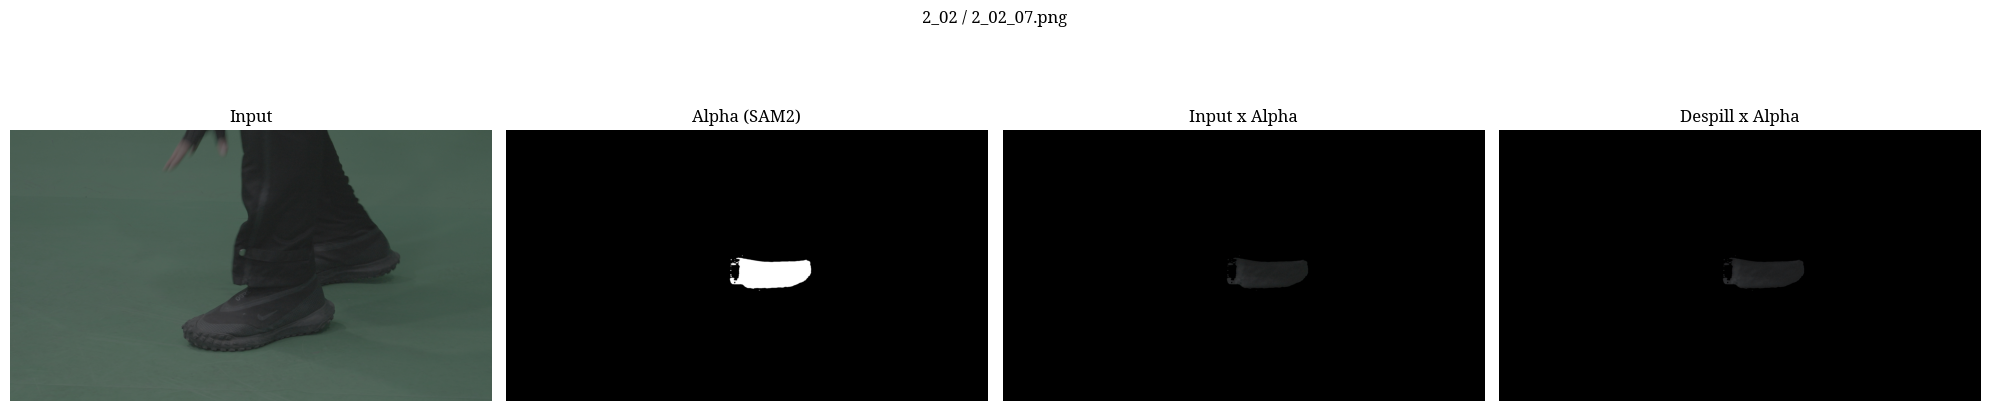

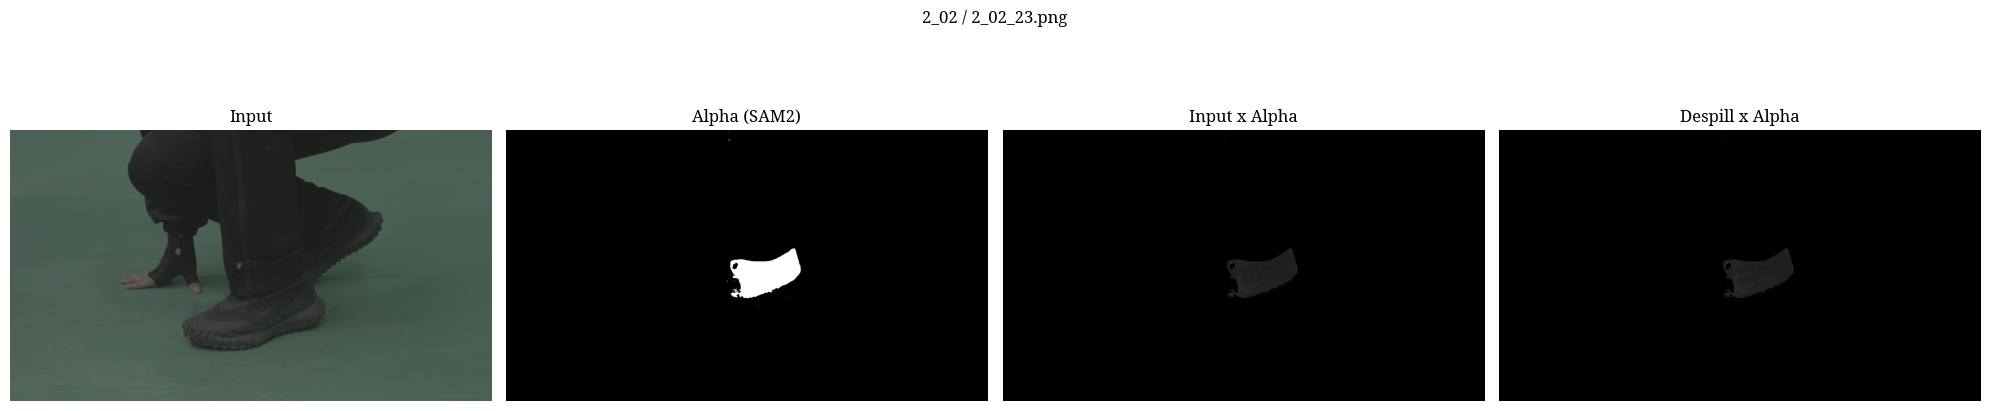

In [8]:
import random

to_tensor = transforms.ToTensor()

def predict_frame(folder, filename):
    image = to_tensor(Image.open(os.path.join(IMAGE_PATH, folder, filename)).convert('RGB'))
    fg_gt = to_tensor(Image.open(os.path.join(FG_PATH,    folder, filename)).convert('RGB'))

    # run sam2 with center point 
    image_uint8 = np.array(Image.open(os.path.join(IMAGE_PATH, folder, filename)).convert('RGB'))
    h, w = image_uint8.shape[:2]
    predictor.set_image(image_uint8)
    masks, scores, _ = predictor.predict(
        point_coords=np.array([[w // 2, h // 2]]),
        point_labels=np.array([1]),
        multimask_output=True,
    )
    alpha_np = masks[np.argmax(scores)].astype(np.float32)  # [H, W] 0 or 1  二值mask
    alpha    = torch.from_numpy(alpha_np).unsqueeze(0)       # [1, H, W]

    image_gpu = image.unsqueeze(0).to(DEVICE)
    alpha_gpu = alpha.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            pred = model(image_gpu, alpha_gpu)
        pred = despill_postprocess(pred.float(), alpha_gpu, strength=0.8)

    def to_np(t):

        return t.squeeze().cpu().float().permute(1,2,0).numpy() if t.dim() == 4 else t.squeeze().cpu().float().numpy()

    return (
        image.permute(1,2,0).numpy(),  
        alpha_np,                       
        to_np(pred),                    
    )


FOLDER     = '2_02'
all_frames = sorted(os.listdir(os.path.join(IMAGE_PATH, FOLDER)))
frames     = random.sample(all_frames, min(5, len(all_frames)))

for fname in frames:
    image_np, alpha_np, pred_np = predict_frame(FOLDER, fname)

    alpha_3ch = alpha_np[:, :, np.newaxis]

    col1 = np.clip(image_np,             0, 1)  
    col2 = alpha_np                              
    col3 = np.clip(image_np * alpha_3ch, 0, 1)  
    col4 = np.clip(pred_np  * alpha_3ch, 0, 1)  

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'{FOLDER} / {fname}', fontsize=12)

    axes[0].imshow(col1);              axes[0].set_title('Input')
    axes[1].imshow(col2, cmap='gray'); axes[1].set_title('Alpha (SAM2)')
    axes[2].imshow(col3);              axes[2].set_title('Input x Alpha')
    axes[3].imshow(col4);              axes[3].set_title('Despill x Alpha')

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()


In [9]:
def get_prompt_points(image_rgb):
    H, W = image_rgb.shape[:2]

    # rough green mask via hsv  
    hsv        = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    green_mask = cv2.inRange(hsv, np.array([35, 40, 40]), np.array([85, 255, 255]))
    fg_mask    = 255 - green_mask  # flip to fg  

    # close op to fill holes, kernel=50 works better  
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (50, 50))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)

    fg_pixels = np.argwhere(fg_mask > 0)  # (row, col)

    if len(fg_pixels) >= 8:
        # sort top to bottom, pick 8 evenly  
        fg_pixels_sorted = fg_pixels[fg_pixels[:, 0].argsort()]
        idx    = np.linspace(0, len(fg_pixels_sorted) - 1, 8, dtype=int)
        fg_pts = fg_pixels_sorted[idx][:, ::-1]  # row,col -> x,y
    else:
        fg_pts = np.array([[W // 2, H // 2]])

    # force a top center point to cover head  
    top_pt = np.array([[W // 2, H // 8]])
    fg_pts = np.vstack([fg_pts, top_pt])

    # four corners as bg  
    bg_pts = np.array([[5, 5], [W-5, 5], [5, H-5], [W-5, H-5]])

    point_coords = np.vstack([fg_pts, bg_pts])
    point_labels = np.array([1]*len(fg_pts) + [0]*4)  # 1=fg 0=bg
    return point_coords, point_labels


In [10]:
def predict_frame_test_with_gt(img_path):
    
    image          = cv2.imread(img_path)
    image          = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image.shape[:2]
    image_np       = image.astype(np.float32) / 255.0

    # improved prompt points + sam2  
    point_coords, point_labels = get_prompt_points(image)
    predictor.set_image(image)
    masks, scores, _ = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True,
    )
    alpha_np = masks[np.argmax(scores)].astype(np.float32)  # [H, W]

    # resize to infer size then back  
    image_small = cv2.resize(image_np, (INFER_SIZE, INFER_SIZE))
    alpha_small = cv2.resize(alpha_np, (INFER_SIZE, INFER_SIZE))

    image_t = torch.from_numpy(image_small).permute(2,0,1).unsqueeze(0).float().to(DEVICE)
    alpha_t = torch.from_numpy(alpha_small).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pred = model(image_t, alpha_t)

    pred_np = pred.squeeze(0).permute(1,2,0).cpu().numpy()
    pred_np = cv2.resize(pred_np, (w_orig, h_orig))  # back to original size  

    return image_np, pred_np, alpha_np, h_orig, w_orig


def get_fg_path(fname):
    stem   = os.path.splitext(fname)[0]
    parts  = stem.split('_')
    folder = '_'.join(parts[:2])
    return os.path.join(FG_DIR, folder, fname)


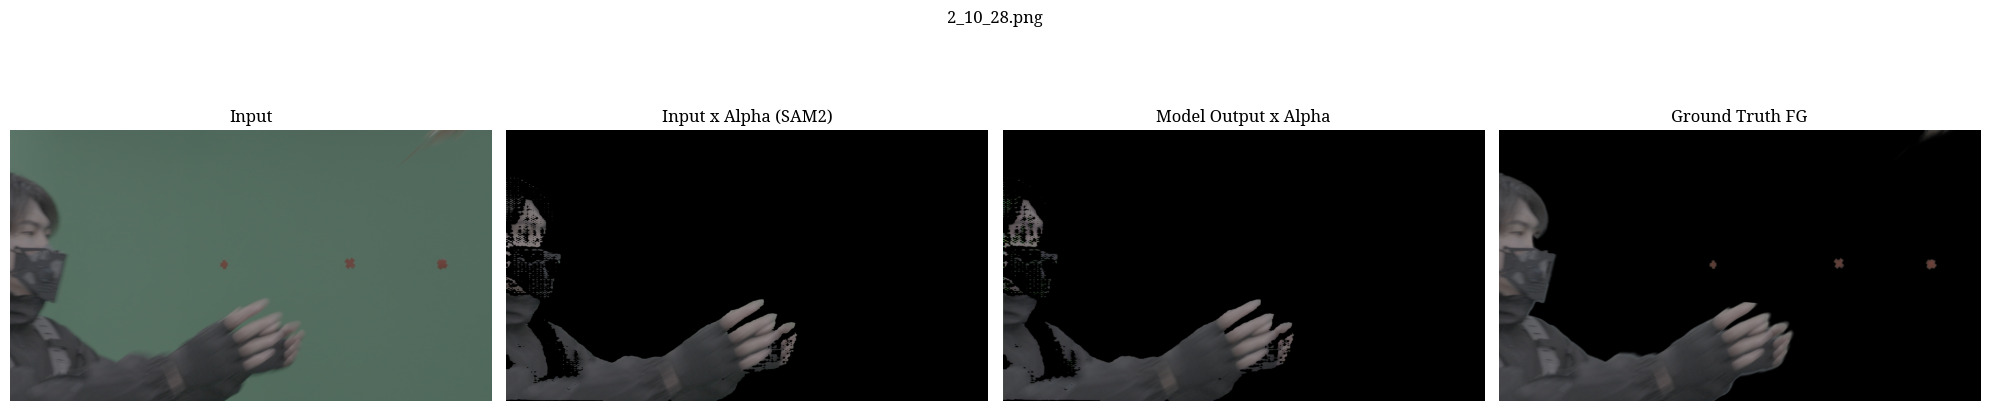

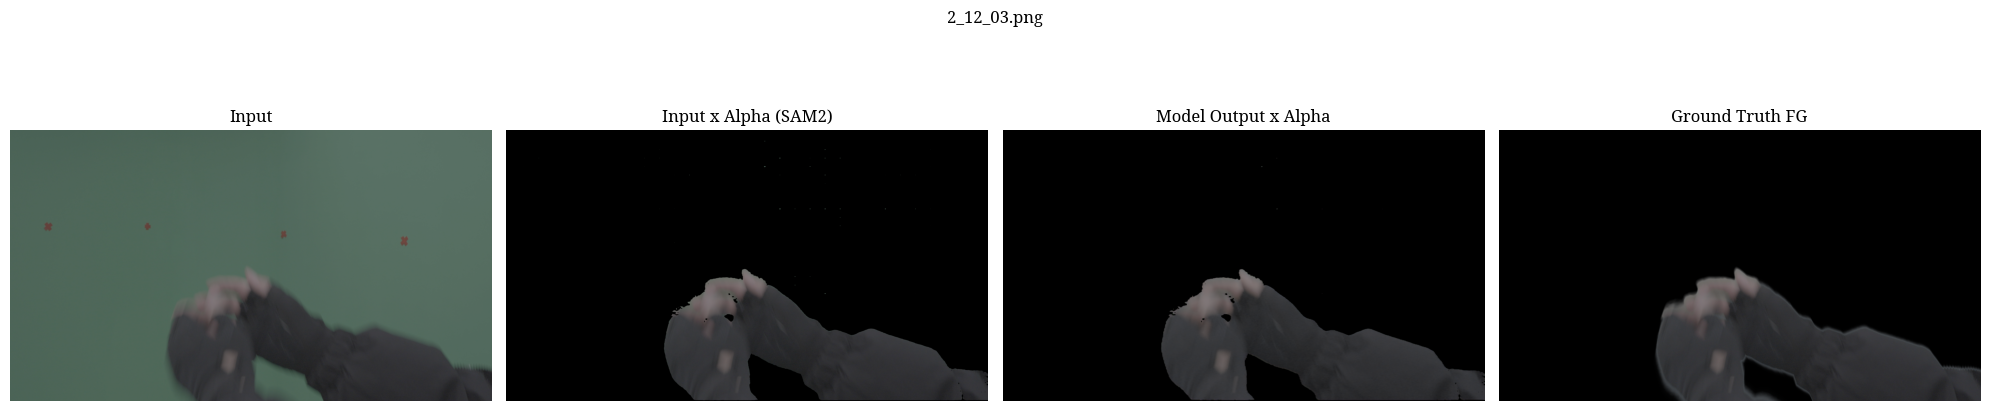

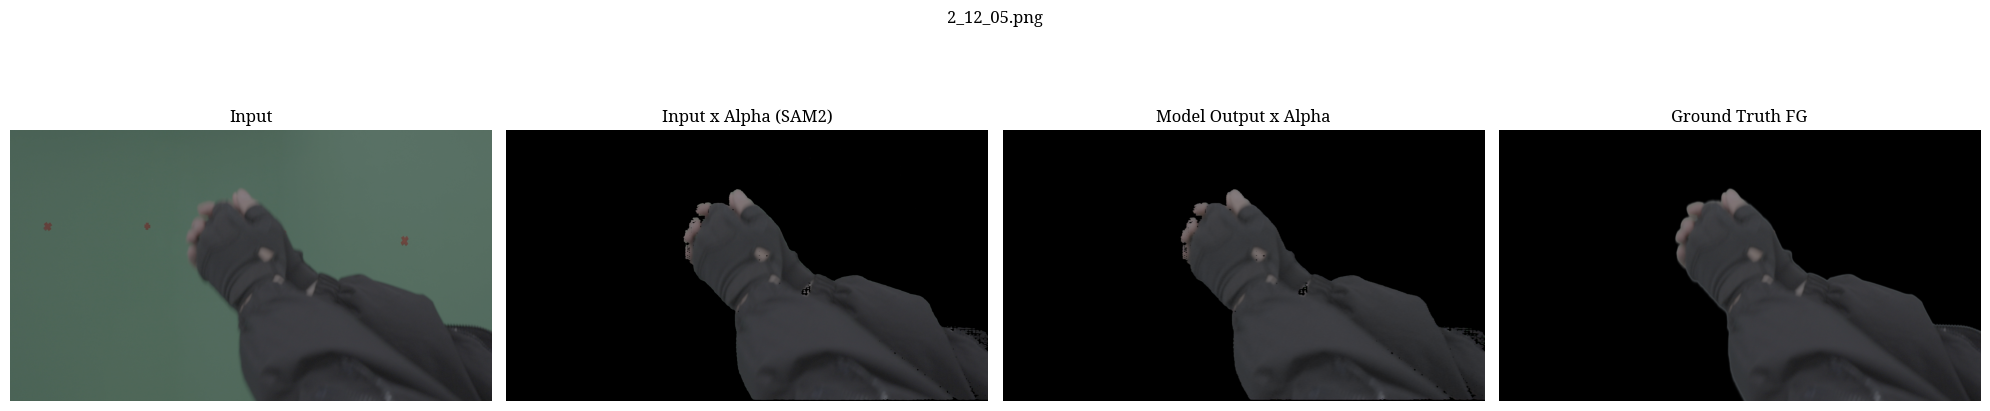

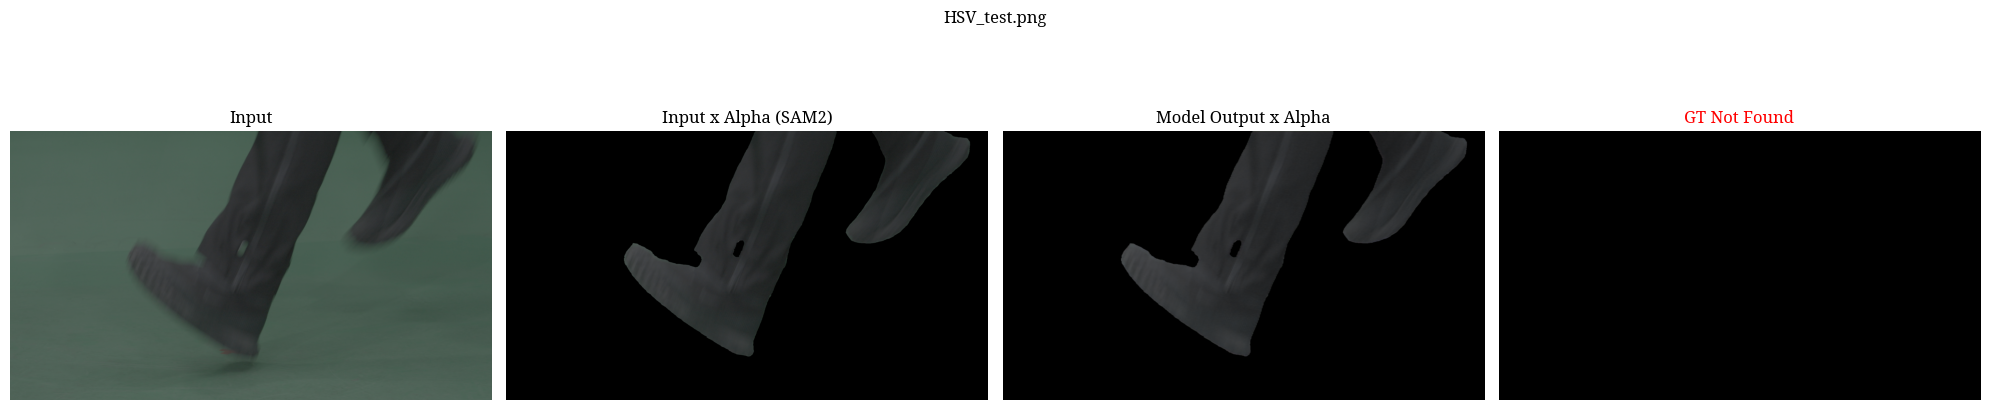

In [11]:
test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

for fname in test_files:
    img_path = os.path.join(TEST_DIR, fname)
    fg_path  = get_fg_path(fname)

    image_np, pred_np, alpha_np, h_orig, w_orig = predict_frame_test_with_gt(img_path)
    torch.cuda.empty_cache()

    alpha_3ch = alpha_np[:, :, np.newaxis]
    col1 = np.clip(image_np,             0, 1)     
    col2 = np.clip(image_np * alpha_3ch, 0, 1)    
    col3 = np.clip(pred_np  * alpha_3ch, 0, 1)  

    # load gt if exists  
    if os.path.exists(fg_path):
        fg_gt = cv2.imread(fg_path, cv2.IMREAD_UNCHANGED).astype(np.float32) / 255.0
        fg_gt = cv2.resize(fg_gt, (w_orig, h_orig))
        if fg_gt.ndim == 3 and fg_gt.shape[2] == 4:
            # rgba, premultiply  
            fg_rgba = cv2.cvtColor(fg_gt, cv2.COLOR_BGRA2RGBA)
            col4    = np.clip(fg_rgba[:, :, :3] * fg_rgba[:, :, 3:4], 0, 1)
        else:
            col4 = np.clip(fg_gt[:, :, ::-1], 0, 1)  # bgr -> rgb
        gt_found = True
    else:
        col4     = np.zeros_like(col1)  
        gt_found = False

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(fname, fontsize=12)

    axes[0].imshow(col1); axes[0].set_title('Input')
    axes[1].imshow(col2); axes[1].set_title('Input x Alpha (SAM2)')
    axes[2].imshow(col3); axes[2].set_title('Model Output x Alpha')
    axes[3].imshow(col4); axes[3].set_title(
        'Ground Truth FG' if gt_found else 'GT Not Found',
        color='black' if gt_found else 'red'
    )

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
